# Performance Metrics Classification Workshop

## Solved workshop with reusable Object-Oriented Python modules

Names:

- Senay
- Seynep
- Ricardo
- Juan Chirivi - ID 9115141  

This notebook follows all **13 “To the student” blocks** in the supplied instructor notebook, including its introductory questions, and completes the final Random Forest comparison. Four reusable classes in `src/` handle datasets, classifiers, metrics, and visualization. Code comments and method docstrings are in English for study.


### To the student 1 — Classification and classifiers

- What are we trying to solve in a classification problem?
- What is a classifier?

*Answer*

Based on a bank of predefined images (MNIST) it is intended to train the program to identify a digitally generated image to which number belongs, by means of an algorithm that scans the characteristics of the image comparing with the original database, and take a decision to decide which number is the image 

A classifier is an algorithm that maps pixels, characteristics, or images of an initial base by assigning a label, which helps to recognize patterns to make descents based on those same patterns, general steps:

- Data Entry: A large number of examples are entered along with their correct answers. In the case of images, the numeric values representing how light or dark is each point in the photo
- Pattern Detection: The classifier looks for mathematical patterns
- Decision Rule: With these patterns, construct a "decision limit" (a mathematical boundary).
- Prediction: When you receive a new unlabeled photo, check which side of the limit the pixel information falls on and take the decision

## 1. Setup and project imports

The notebook coordinates the workflow; the implementation lives in reusable Python modules. `ImageDataLoader` loads and splits data, `ClassificationModel` trains and validates estimators, `ClassificationMetrics` evaluates predictions, and `ClassificationVisualizer` draws charts.

In [22]:
# Import the four reusable project classes and reporting tools.
from pathlib import Path
import sys
import platform
import numpy as np
import pandas as pd
import sklearn
from matplotlib import pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    candidate = Path.cwd().parent
    if (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
    else:
        raise FileNotFoundError("Open the notebook from the extracted project folder.")

sys.path.insert(0, str(PROJECT_ROOT))

from src import (
    ImageDataLoader, ClassificationModel,
    ClassificationMetrics, ClassificationVisualizer,
)

# Keep downloads separate from the source files committed to GitHub.
CACHE_DIR = PROJECT_ROOT / ".cache" / "openml"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
CV_FOLDS = 3
visualizer = ClassificationVisualizer()
print(f"Python {platform.python_version()} | scikit-learn {sklearn.__version__}")

Python 3.14.3 | scikit-learn 1.9.1


## 2. Obtain and explore MNIST

Each row of `X` contains 784 raw pixel values describing one 28 × 28 grayscale image. Each entry in `y` is its digit label. We keep raw pixels and the default SGD configuration to follow the instructor's experiment. In an improved SGD pipeline, scaling could be fitted separately within each training fold.

Feature shape: (70000, 784) Label shape: (70000,)
Pixel range: 0.0 to 255.0


,Images per digit
0,6903
1,7877
2,6990
3,7141
4,6824
5,6313
6,6876
7,7293
8,6825
9,6958


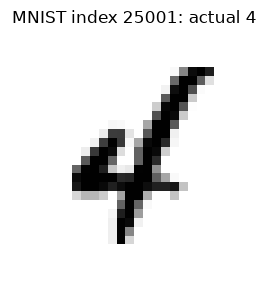

In [23]:
# Download/cache the real MNIST dataset and inspect its dimensions.
mnist_loader = ImageDataLoader("mnist", CACHE_DIR)
X, y = mnist_loader.load_data()
print("Feature shape:", X.shape, "Label shape:", y.shape)
print("Pixel range:", X.min(), "to", X.max())
display(pd.Series(y).value_counts().sort_index().rename("Images per digit").to_frame())

# Show the original notebook's earlier example with its matching label.
visualizer.plot_image(X[25001], title=f"MNIST index 25001: actual {y[25001]}")
plt.show()

## 3. Preprocess the data and define the binary target

We preserve the original 60,000/10,000 split. Cross-validation uses only the training partition. The final test partition stays separate from threshold selection and model comparisons during development.

Training: (60000, 784) Testing: (10000, 784)
First five binary labels: [ True False False False False]
Training 5 prevalence: 9.04%


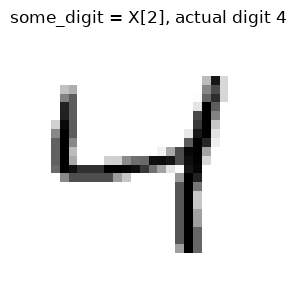

In [24]:
# Split features and original digit labels, then create 5-versus-not-5 targets.
X_train, X_test, y_train, y_test = mnist_loader.split_data(X, y)
y_train_5 = mnist_loader.prepare_binary_target(y_train, positive_label="5")
y_test_5 = mnist_loader.prepare_binary_target(y_test, positive_label="5")
print("Training:", X_train.shape, "Testing:", X_test.shape)
print("First five binary labels:", y_train_5[:5])
print(f"Training 5 prevalence: {y_train_5.mean():.2%}")

# The instructor overwrites some_digit with X[2]; retain that exact example.
some_digit = X[2]
visualizer.plot_image(some_digit, title=f"some_digit = X[2], actual digit {y[2]}")
plt.show()

### To the student 2 — Boolean targets and unchanged features

- What do True and False stand for in `y_train_5`?
- Why wasn't `X` changed as well?

**Answer**

`True` means the image's actual digit is 5, the positive class. `False` means its actual digit is any other digit, the negative class. These are ground-truth labels, not predictions.

`X` stays the same because every image is still described by the same pixels. Only the question and target labels changed: ten digit categories became two categories, 5 and not-5. Non-5 images are necessary negative training examples, so we keep them.

## 4. Train the SGD classifier and predict one image

`SGDClassifier(random_state=42)` defaults to hinge loss (a linear SVM trained with stochastic gradient descent), L2 regularization, `alpha=0.0001`, and `max_iter=1000`. The seed controls random training behavior. A decision score indicates which side of the learned boundary a sample lies on; it is not a calibrated probability.

In [25]:
# Fit the model on the training partition and classify the selected example.
sgd_model = ClassificationModel("sgd", random_state=42)
sgd_model.train(X_train, y_train_5)
some_prediction = bool(sgd_model.predict(some_digit.reshape(1, -1))[0])
print("Selected image index:", 2)
print("Actual digit:", y[2])
print("Actual positive class:", bool(y_train_5[2]))
print("Predicted positive class:", some_prediction)

Selected image index: 2
Actual digit: 4
Actual positive class: False
Predicted positive class: False


### To the student 3 — Interpret some_digit and its prediction

- Which image does `some_digit` stand for?
- What does the predicted Boolean value mean?

**Answer**

At prediction time, `some_digit` is `X[2]`, the **third image**, because Python indexes from zero. It is no longer `X[25001]`. Its matching label is `y[2]`; using `y[0]` would describe a different image.

A predicted `True` means “the model thinks this is a 5.” A predicted `False` means “the model thinks this is not a 5.” The prediction is correct only if it matches the actual Boolean target.

In [26]:
# Generate a concrete interpretation from the actual result.
display(Markdown(
    f"The third image is digit **{y[2]}**. The model predicts **{some_prediction}**, "
    f"so it labels this image **{'5' if some_prediction else 'not-5'}**. "
    f"This prediction is **{'correct' if some_prediction == bool(y_train_5[2]) else 'incorrect'}**. "
    "This image was used in training, so it demonstrates prediction syntax, not generalization."
))

The third image is digit **4**. The model predicts **False**, so it labels this image **not-5**. This prediction is **correct**. This image was used in training, so it demonstrates prediction syntax, not generalization.

## 5. Accuracy and cross-validation

Accuracy = (TP + TN) / (TP + TN + FP + FN). A fold is one validation portion of the training partition. With three stratified folds, each run trains on two folds and validates on the remaining fold. Stratification approximately preserves class proportions.

In [27]:
# Obtain a separate accuracy and timing measurement for each validation fold.
sgd_cv = sgd_model.evaluate_cv(X_train, y_train_5, cv=CV_FOLDS)
sgd_cv_table = pd.DataFrame(sgd_cv, index=["Fold 1", "Fold 2", "Fold 3"])
display(sgd_cv_table)

,fit_time,score_time,test_score
Fold 1,9.559793,0.022379,0.95035
Fold 2,9.107871,0.022835,0.96035
Fold 3,7.306443,0.025055,0.96040


### To the student 4 — Understand cross_validate

- What is `cv` for?
- How many times was the model trained?
- How does `cv` relate to the output?
- What are `fit_time`, `score_time`, and `test_score`?

*Answer*

- `cv`Define the strategy to divide the data and test the model. If you put cv=3, the data is divided into 3 parts (blocks). The model is trained 3 different times, using in each turn 2 parts to train and 1 part to validate.

- It worked 3 times in total within the CV (one for each block).

- As the program did 3 tests, the answer you get is not a single number, but a list of 3 results (one result for each processed block).

- `fit_time` is training time in seconds, `score_time` The time in seconds it took to calculate the grade, and `test_score` is its accuracy because `scoring="accuracy"`.


### To the student 5 — Interpret accuracy and the handwritten rule

- Describe first-fold accuracy in terms of 100 digits.
- What simple handwritten rule achieves 90% accuracy under uniform labels?
- How good is SGD compared with that rule?

**Answer**

- If you take a sample of 100 images from the first test group, accuracy tells you how many photos did the model classify well and how many did wrong, for example, if it has 95% accuracy, it hit 95 out of 100 and got 5 wrong

- The rule is 'Always say it’s not a 5', If we assume that all numbers from 0 to 9 represent 10% each, 90% of the photos DO NOT have a 5, so it would follow the rule even if equated with the real 5

- To know if the SGD model works, the model’s accuracy has to be higher than 90% of the previous rule; however, more rules are needed to confirm a more accurate precision such as precision and sensitivity.

In [28]:
# Express the actual fold score in plain English and compute the naive baseline.
first_accuracy = float(sgd_cv["test_score"][0])
naive_accuracy = float((~y_train_5).mean())
display(Markdown(
    f"Out of 100 validation digits, approximately **{100 * first_accuracy:.2f}** "
    f"are correctly classified and **{100 * (1 - first_accuracy):.2f}** incorrectly classified. "
    f"The first-fold SGD accuracy is **{first_accuracy:.2%}**. "
    f"The always-not-5 accuracy on the full training partition is **{naive_accuracy:.2%}**."
))

Out of 100 validation digits, approximately **95.03** are correctly classified and **4.96** incorrectly classified. The first-fold SGD accuracy is **95.03%**. The always-not-5 accuracy on the full training partition is **90.96%**.

## 6. DummyClassifier baseline

The explicit `most_frequent` strategy predicts the majority label, False, for every image. It learns the majority from labels and ignores image features.

In [29]:
# Evaluate the majority-class baseline with the same folds as SGD.
dummy_model = ClassificationModel("dummy")
dummy_model.train(X_train, y_train_5)
dummy_cv = dummy_model.evaluate_cv(X_train, y_train_5, cv=CV_FOLDS)
display(pd.DataFrame({
    "SGD accuracy": sgd_cv["test_score"],
    "Dummy accuracy": dummy_cv["test_score"],
}, index=["Fold 1", "Fold 2", "Fold 3"]))
print("Any positive dummy predictions?", bool(dummy_model.predict(X_train).any()))

,SGD accuracy,Dummy accuracy
Fold 1,0.95035,0.90965
Fold 2,0.96035,0.90965
Fold 3,0.96040,0.90965


Any positive dummy predictions? False


### To the student 6 — Compare DummyClassifier and SGD

- What is DummyClassifier's accuracy?
- How does it compare with the handwritten rule and SGD?

**Answer**

- Its accuracy is close to 90%, this is due to the rule 'Always say it’s not a 5'.
- The SGD model examine the pixels in the image to learn the visual pattern of number 5, whereas the handwritten rule does not validate any number; it is only favored by statistical

In [30]:
# Report the measured comparison rather than a hard-coded example score.
sgd_mean_accuracy = float(np.mean(sgd_cv["test_score"]))
dummy_mean_accuracy = float(np.mean(dummy_cv["test_score"]))
display(Markdown(
    f"Mean Dummy accuracy: **{dummy_mean_accuracy:.2%}**. "
    f"Mean SGD accuracy: **{sgd_mean_accuracy:.2%}**. "
    f"SGD differs from Dummy by **{100 * (sgd_mean_accuracy - dummy_mean_accuracy):+.2f} percentage points**."
))

Mean Dummy accuracy: **90.96%**. Mean SGD accuracy: **95.70%**. SGD differs from Dummy by **+4.74 percentage points**.

### To the student 7 — Fashion-MNIST challenge

Obtain Fashion-MNIST, preprocess it, train a model, evaluate it, and explain whether the process can be replicated.

**Answer**

Yes, the process can be replicated, The algorithm doesn’t care what the image really is; it just sees a matrix of pixels (numbers from 0 to 255) and applies the same mathematical operations.

Although the process can be replicated, this does not mean that the accuracy is the same; differentiating between more complex images can become more difficult than differentiating a 5 from a 3 or an 8. The image size is equal, but the visual complexity changes.

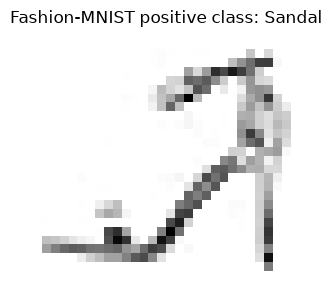

,SGD accuracy,Dummy accuracy
Fold 1,0.97645,0.9
Fold 2,0.97755,0.9
Fold 3,0.97075,0.9


,accuracy,precision,recall,f1
Fashion SGD: out-of-fold,0.974917,0.881773,0.865167,0.873391


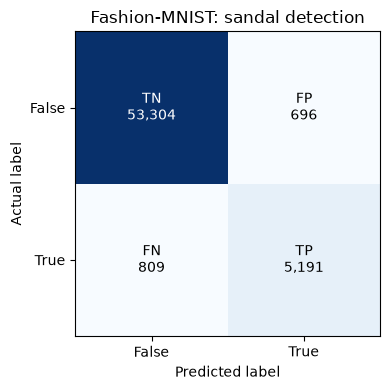

Sandal prevalence is **10.00%**. Out-of-fold SGD precision is **88.18%** and recall is **86.52%**. These positive-class metrics show what the 90% majority baseline hides.

In [31]:
# Load clothing images, preserve the split, and create sandal-versus-other targets.
fashion_loader = ImageDataLoader("fashion_mnist", CACHE_DIR)
X_fashion, y_fashion = fashion_loader.load_data()
X_ftrain, X_ftest, y_ftrain, y_ftest = fashion_loader.split_data(X_fashion, y_fashion)
y_ftrain_5 = fashion_loader.prepare_binary_target(y_ftrain, "5")
y_ftest_5 = fashion_loader.prepare_binary_target(y_ftest, "5")
sandal_index = int(np.flatnonzero(y_ftrain_5)[0])
visualizer.plot_image(X_ftrain[sandal_index], "Fashion-MNIST positive class: Sandal")
plt.show()

# Validate both models on training data; reserve test images for the final section.
fashion_model = ClassificationModel("sgd", random_state=42)
fashion_dummy = ClassificationModel("dummy")
fashion_cv = fashion_model.evaluate_cv(X_ftrain, y_ftrain_5, cv=CV_FOLDS)
fashion_dummy_cv = fashion_dummy.evaluate_cv(X_ftrain, y_ftrain_5, cv=CV_FOLDS)
fashion_oof_pred = fashion_model.out_of_fold(X_ftrain, y_ftrain_5, cv=CV_FOLDS)
fashion_metrics = ClassificationMetrics(y_ftrain_5, fashion_oof_pred)
fashion_summary = fashion_metrics.summary()
display(pd.DataFrame({
    "SGD accuracy": fashion_cv["test_score"],
    "Dummy accuracy": fashion_dummy_cv["test_score"],
}, index=["Fold 1", "Fold 2", "Fold 3"]))
display(pd.DataFrame([fashion_summary], index=["Fashion SGD: out-of-fold"]))
visualizer.plot_confusion_matrix(fashion_metrics.confusion_matrix(), "Fashion-MNIST: sandal detection")
plt.show()

# Fit a final model on the full Fashion-MNIST training partition.
fashion_model.train(X_ftrain, y_ftrain_5)
display(Markdown(
    f"Sandal prevalence is **{y_ftrain_5.mean():.2%}**. "
    f"Out-of-fold SGD precision is **{fashion_summary['precision']:.2%}** "
    f"and recall is **{fashion_summary['recall']:.2%}**. "
    "These positive-class metrics show what the 90% majority baseline hides."
))

## 7. Confusion matrix

Out-of-fold predictions ensure each training image is predicted by a model that did not train on that image. These predictions support evaluation; they do not replace the final fitted model. With Boolean labels ordered `[False, True]`, rows are actual labels and columns are predicted labels.

Evaluated images: 60000
Actual validation counts: {'TN': 53892, 'FP': 687, 'FN': 1891, 'TP': 3530}
Perfect reference matrix:
 [[54579     0]
 [    0  5421]]


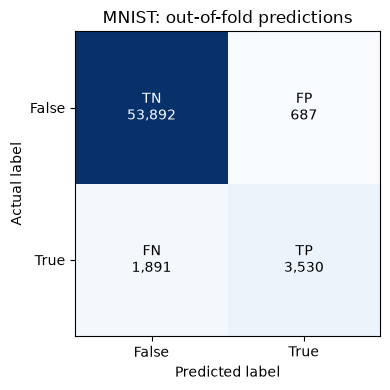

In [32]:
# Generate validation predictions and compare them with the known targets.
y_train_pred = sgd_model.out_of_fold(X_train, y_train_5, cv=CV_FOLDS)
mnist_metrics = ClassificationMetrics(y_train_5, y_train_pred)
cm = mnist_metrics.confusion_matrix()
counts = mnist_metrics.counts()
perfect_cm = ClassificationMetrics(y_train_5, y_train_5).confusion_matrix()
print("Evaluated images:", cm.sum())
print("Actual validation counts:", counts)
print("Perfect reference matrix:\n", perfect_cm)
visualizer.plot_confusion_matrix(cm, "MNIST: out-of-fold predictions")
plt.show()

### To the student 8 — Interpret both confusion matrices

- What arguments does `confusion_matrix` require?
- What is its binary-classifier output?
- What does each value mean in the measured and perfect matrices?

**Answer**

The required arguments are `y_true` (actual labels) and `y_pred` (predicted labels). The output here is a 2 × 2 count array; we explicitly set `labels=[False, True]` to fix its order.

| Position | Count | Meaning for 5 detection |
|---|---|---|
| [0, 0] | TN | Actual non-5 correctly predicted non-5 |
| [0, 1] | FP | Actual non-5 incorrectly predicted 5 |
| [1, 0] | FN | Actual 5 incorrectly predicted non-5 |
| [1, 1] | TP | Actual 5 correctly predicted 5 |

The perfect reference matrix compares truth with itself: FP = FN = 0, TN equals the number of non-5 images, and TP equals the number of actual 5s. This is an illustration of the matrix, not a trained model achieving perfection.

In [33]:
# State the meaning of the actual numeric cells in both matrices.
display(Markdown(
    f"Measured matrix: **TN={counts['TN']:,}**, **FP={counts['FP']:,}**, "
    f"**FN={counts['FN']:,}**, **TP={counts['TP']:,}**. "
    f"Perfect reference: **TN={perfect_cm[0, 0]:,}**, **FP=0**, **FN=0**, "
    f"**TP={perfect_cm[1, 1]:,}**. Both account for **{cm.sum():,}** training images."
))

Measured matrix: **TN=53,892**, **FP=687**, **FN=1,891**, **TP=3,530**. Perfect reference: **TN=54,579**, **FP=0**, **FN=0**, **TP=5,421**. Both account for **60,000** training images.

## 8. Precision and recall

Precision = TP / (TP + FP): among positive predictions, how many are correct?  
Recall = TP / (TP + FN): among actual positives, how many were found?

In [34]:
# Evaluate the positive class using scikit-learn metrics wrapped in our class.
mnist_summary = mnist_metrics.summary()
display(pd.DataFrame([mnist_summary], index=["MNIST SGD: out-of-fold"]))
manual_precision = ClassificationMetrics.manual_precision(counts["TP"], counts["FP"])
print(f"Manual precision = {counts['TP']} / ({counts['TP']} + {counts['FP']}) = {manual_precision:.6f}")

,accuracy,precision,recall,f1
MNIST SGD: out-of-fold,0.957033,0.837088,0.651171,0.732517


Manual precision = 3530 / (3530 + 687) = 0.837088


### To the student 9 — Autonomous security drone

500 views; 10 actual person-present views; 12 alarms; 8 correct alarms. Calculate precision and recall, show the fractions, and interpret the results.

**Answer**

Positive means **person present in a restricted area**. TP = 8, FP = 12 − 8 = 4, FN = 10 − 8 = 2, and TN = 500 − 8 − 4 − 2 = 486.

**Precision = 8 / (8 + 4) = 8/12 = 66.67%.** About two-thirds of alarms correctly identify a person; one-third are false alarms.

**Recall = 8 / (8 + 2) = 8/10 = 80%.** The drone finds 8 of the 10 actual person-present views and misses 2.

Its accuracy is 494/500 = 98.8%, yet it still misses 20% of intrusions. This shows why accuracy alone can hide important errors when positive cases are rare.

In [35]:
# Reproduce the drone calculations using reusable manual-metric methods.
drone_tp, drone_fp, drone_fn, drone_tn = 8, 4, 2, 486
print(f"Precision: 8/12 = {ClassificationMetrics.manual_precision(drone_tp, drone_fp):.2%}")
print(f"Recall: 8/10 = {ClassificationMetrics.manual_recall(drone_tp, drone_fn):.2%}")
print(f"Accuracy: 494/500 = {(drone_tp + drone_tn) / 500:.2%}")

Precision: 8/12 = 66.67%
Recall: 8/10 = 80.00%
Accuracy: 494/500 = 98.80%


### To the student 10 — Calculate recall manually

Write Python code to calculate recall from the confusion matrix, similar to the manual precision calculation.

**Answer**

In the `[False, True]` matrix order, TP is `cm[1, 1]` and FN is `cm[1, 0]`. Recall is therefore `cm[1, 1] / (cm[1, 1] + cm[1, 0])`. The method below implements the same formula and handles a zero denominator.

In [36]:
# Read TP and FN from the confusion matrix and calculate recall directly.
tp = int(cm[1, 1])
fn = int(cm[1, 0])
manual_recall = tp / (tp + fn) if tp + fn else 0.0
print(f"Recall = {tp} / ({tp} + {fn}) = {manual_recall:.6f}")
print("Reusable method:", ClassificationMetrics.manual_recall(tp, fn))
print("scikit-learn result:", mnist_summary["recall"])
np.testing.assert_allclose(manual_recall, mnist_summary["recall"])

Recall = 3530 / (3530 + 1891) = 0.651171
Reusable method: 0.6511713705958311
scikit-learn result: 0.6511713705958311


## 9. F1 score and harmonic mean

F1 = 2 × TP / (2 × TP + FP + FN). It combines precision and recall through their harmonic mean and ignores true negatives. It is useful when both positive-class goals matter, but does not encode unequal error costs.

### To the student 11 — Calculate F1 manually

Use TP, FP, and FN to calculate the F1 score generated above in a Python cell.

**Answer**

The direct count formula is **2TP / (2TP + FP + FN)**. The code extracts actual validation counts and compares its result with the library metric; it does not assume the instructor's example F1 value.

F1 = 7060 / (7060 + 687 + 1891) = 0.732517
Reusable method: 0.7325171197343847
scikit-learn result: 0.7325171197343847


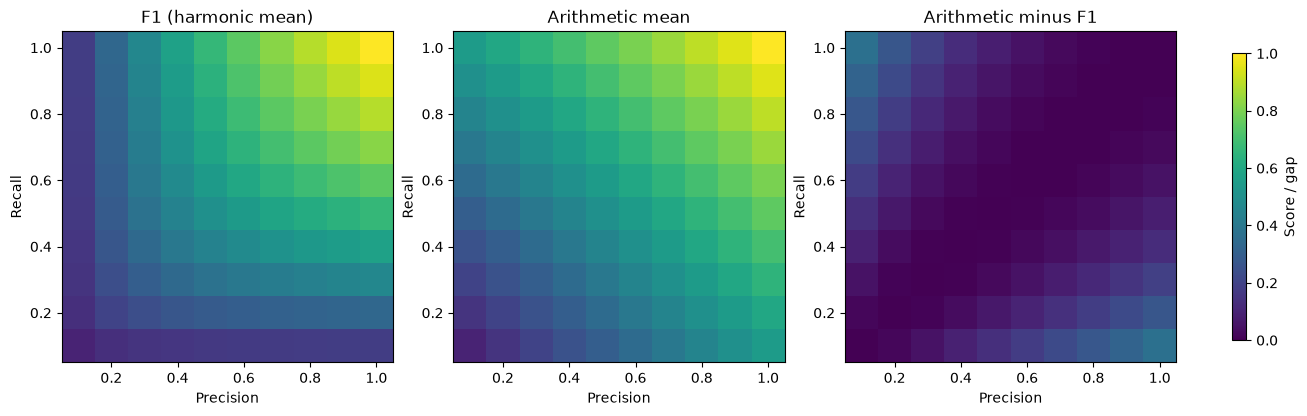

In [37]:
# Compute F1 from the confusion matrix without calling the library formula.
fp = int(cm[0, 1])
manual_f1 = (2 * tp) / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0
print(f"F1 = {2 * tp} / ({2 * tp} + {fp} + {fn}) = {manual_f1:.6f}")
print("Reusable method:", ClassificationMetrics.manual_f1(tp, fp, fn))
print("scikit-learn result:", mnist_summary["f1"])
np.testing.assert_allclose(manual_f1, mnist_summary["f1"])

# Compare how two different averages reward balanced precision and recall.
visualizer.plot_mean_comparison()
plt.show()

The harmonic mean is at most the arithmetic mean, with equality when precision equals recall. For precision 1.0 and recall 0.1, the arithmetic mean is 0.55 but F1 is about 0.182. The gap is largest when the two metrics differ substantially.

## 10. Precision/recall tradeoff and the decision threshold

### To the student 12 — Choose a metric for each application

- Medical screening that decides which patients receive professional review: precision or recall?
- A classifier highlighting the best investment opportunities: precision or recall?
- Add one further case prioritizing recall and one prioritizing precision.

**Answer**

These are hypothetical error-cost examples:

| Scenario | Priority | Reason |
|---|---|---|
| First-stage medical screening | High recall | Missing a true condition could prevent professional review. Extra false positives can be reviewed by a clinician. |
| Shortlist of promising investments | High precision | Assuming costly actions follow recommendations, false positive opportunities are expensive. Some missed opportunities may be acceptable. |
| SOC alert triage for suspected intrusions | High recall | Missing a real intrusion could delay investigation; analysts can inspect additional alerts. |
| Automatic email deletion for suspected spam | High precision | Deleting a legitimate message is costly, so fewer false positive deletions matter even if some spam remains. |

The preferred metric depends on the action and error costs. If an investment model only gathers candidates for inexpensive review, recall could instead be preferred. These examples explain metric selection; they do not claim that one metric alone establishes a safe operational system.

Decision score: -13489.14805778508
Threshold 0: predicted 5 = False
Threshold 3000: predicted 5 = False


,positive_predictions,accuracy,precision,recall,f1
threshold,,,,,
-3000,5823,0.954433,0.730723,0.784911,0.756848
0,4217,0.957033,0.837088,0.651171,0.732517
3000,3022,0.949050,0.891132,0.496772,0.637925


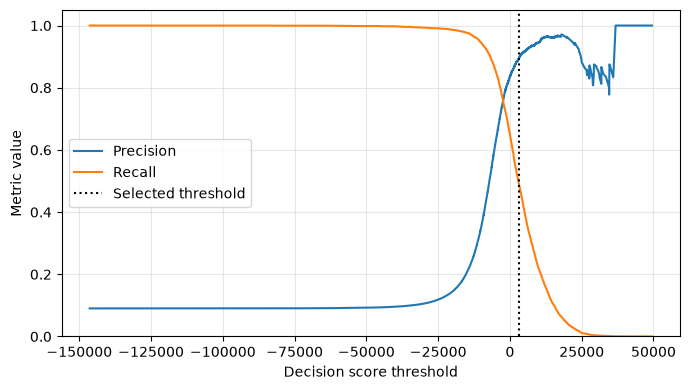

In [38]:
# Compare the selected image's score against two fixed decision thresholds.
some_score = float(sgd_model.decision_scores(some_digit.reshape(1, -1))[0])
print("Decision score:", some_score)
for threshold in [0, 3000]:
    prediction = ClassificationModel.threshold_predictions([some_score], threshold)[0]
    print(f"Threshold {threshold}: predicted 5 = {bool(prediction)}")

# Obtain validation scores for all training images without in-fold training leakage.
y_scores = sgd_model.out_of_fold(
    X_train, y_train_5, cv=CV_FOLDS, method="decision_function"
)
threshold_rows = []
for threshold in [-3000, 0, 3000]:
    threshold_pred = ClassificationModel.threshold_predictions(y_scores, threshold)
    result = ClassificationMetrics(y_train_5, threshold_pred).summary()
    threshold_rows.append({"threshold": threshold, "positive_predictions": int(threshold_pred.sum()), **result})
display(pd.DataFrame(threshold_rows).set_index("threshold"))
visualizer.plot_threshold_curve(y_train_5, y_scores, threshold=3000)
plt.show()

### To the student 13 — Effect of increasing or decreasing the threshold

- How do precision and recall change as the threshold rises or falls?
- What is the intuition?

**Answer**

- If you raise the threshold (the model is more demanding): It predicts less "YES". It escapes more real fifths, so the sensitivity (recall) falls. In return, because he only answers "YES" when he is very sure, accuracy tends to rise (though not always in 100% of cases).
- If you lower the threshold (the model is more permissive): It predicts more "YES". It catches almost all real fifths, so sensitivity rises. But as he lets everything slip by, he makes more mistakes and accuracy falls.
- The intuition is changing the strength of evidence required to call an image a 5. We are only deciding how sure the model should be to say that a photo is a 5.

## 11. Precision-recall curve and a 90% precision threshold

The plotted curve evaluates predictions over many thresholds. The precision and recall arrays have one more entry than the threshold array: the final artificial endpoint has precision 1 and recall 0, with no corresponding threshold. Our selector excludes that endpoint, so it cannot mistake it for an achievable threshold.

We select the highest-recall threshold meeting 90% precision **on training out-of-fold scores**. This is a development result. Its precision can be different on future data or the reserved test set. A pooled out-of-fold threshold is approximate when different folds produce differently scaled scores.

Selected threshold: 3370.0194991439557


,accuracy,precision,recall,f1,roc_auc,average_precision
SGD: selected OOF threshold,0.9482,0.900035,0.479985,0.626083,0.960494,0.810042


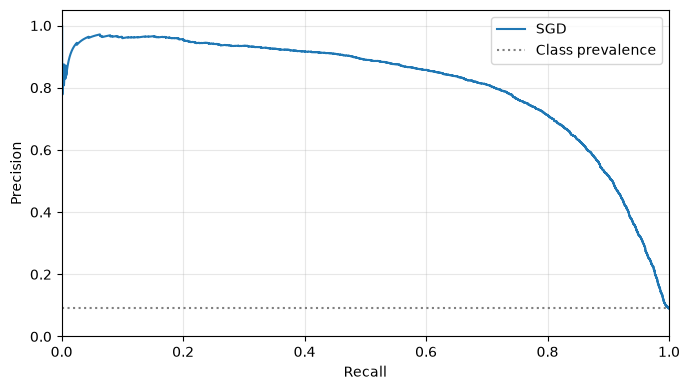

The selected validation threshold achieves precision **90.00%** with recall **48.00%**. The recall value shows the fraction of actual 5s retained while meeting the precision objective.

In [39]:
# Select a valid threshold from training validation scores and evaluate that point.
threshold_90 = ClassificationMetrics.threshold_for_precision(
    y_train_5, y_scores, target_precision=0.90
)
pred_90 = ClassificationModel.threshold_predictions(y_scores, threshold_90)
metrics_90 = ClassificationMetrics(y_train_5, pred_90)
summary_90 = metrics_90.summary(y_scores)
print("Selected threshold:", threshold_90)
display(pd.DataFrame([summary_90], index=["SGD: selected OOF threshold"]))
visualizer.plot_precision_recall(y_train_5, {"SGD": y_scores})
plt.show()
display(Markdown(
    f"The selected validation threshold achieves precision **{summary_90['precision']:.2%}** "
    f"with recall **{summary_90['recall']:.2%}**. "
    "The recall value shows the fraction of actual 5s retained while meeting the precision objective."
))

## 12. ROC curve and ROC AUC

TPR = TP / (TP + FN), which equals recall. FPR = FP / (FP + TN). An ideal ROC operating point is (FPR=0, TPR=1). ROC AUC summarizes ranking ability across thresholds; it is not a guarantee of accuracy, calibration, or good precision at a chosen threshold.

Positive-class rarity does not by itself inflate ROC AUC, but a small FPR can still correspond to many false positives when negatives are numerous. Precision-recall curves make that effect visible. Average precision (AP) summarizes the precision-recall ranking; its no-skill baseline is class prevalence.

,accuracy,precision,recall,f1,roc_auc,average_precision
SGD: default OOF predictions,0.957033,0.837088,0.651171,0.732517,0.960494,0.810042


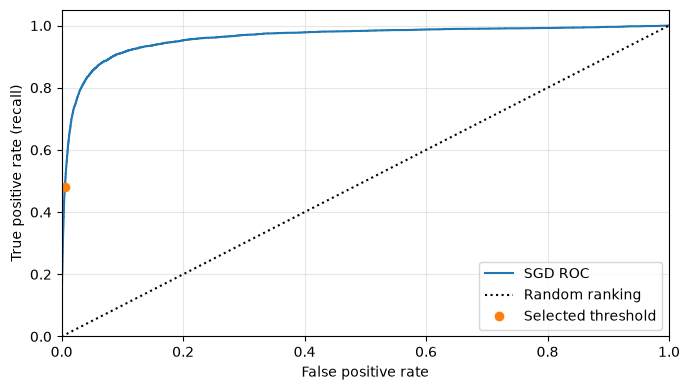

In [40]:
# Use decision scores, rather than hard predictions, for ranking metrics.
sgd_ranked_summary = mnist_metrics.summary(y_scores)
display(pd.DataFrame([sgd_ranked_summary], index=["SGD: default OOF predictions"]))
visualizer.plot_roc(y_train_5, y_scores, threshold=threshold_90)
plt.show()

## 13. Compare Random Forest with SGD

The instructor also compares a Random Forest, even though this final section has no “To the student” heading. We use 100 trees and the same three folds. Out-of-fold probabilities are obtained once, then reused for curves and metrics.

For `[False, True]` classes, a probability tie at 0.5 is resolved as False by the estimator's `predict` argmax. We therefore use `> 0.5` to reproduce that behavior; `>= 0.5` would assign exact ties to True.

,P(not-5),P(5)
0,0.11,0.89
1,0.99,0.01


Probability ties at 0.5: 38
For 364 scores between 0.50 and 0.60, actual 5 share: 93.96%


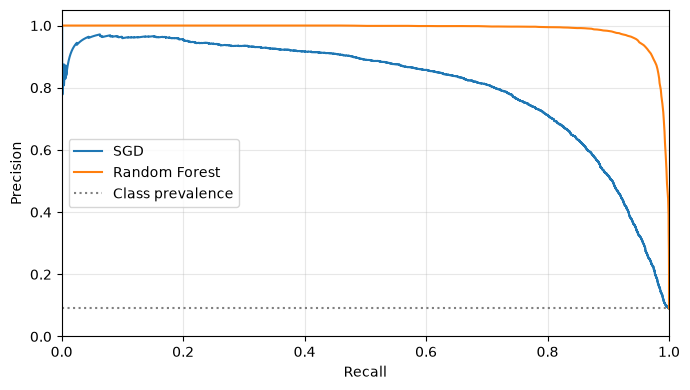

,accuracy,precision,recall,f1,roc_auc,average_precision
SGD,0.957033,0.837088,0.651171,0.732517,0.960494,0.810042
Random Forest,0.987167,0.990508,0.866261,0.924228,0.998344,0.987576


Random Forest validation F1 is **0.9242**, compared with SGD **0.7325**. Compare the measured precision, recall, AP, and ROC AUC together rather than assuming one model is better on every metric. The probability-bin check also shows whether reported forest probabilities match observed frequencies; probabilities need not be calibrated.

In [41]:
# Obtain probabilities from validation models trained without each evaluated image.
forest_model = ClassificationModel("random_forest", random_state=42)
forest_probas = forest_model.out_of_fold(
    X_train, y_train_5, cv=CV_FOLDS, method="predict_proba"
)
# All folds contain both Boolean classes; columns are [False, True].
forest_scores = forest_probas[:, 1]
forest_pred = forest_scores > 0.5
forest_metrics = ClassificationMetrics(y_train_5, forest_pred)
forest_summary = forest_metrics.summary(forest_scores)
display(pd.DataFrame(forest_probas[:2], columns=["P(not-5)", "P(5)"]))
print("Probability ties at 0.5:", int(np.sum(forest_scores == 0.5)))

# Compare the observed positive fraction in the instructor's probability bin.
probability_bin = (forest_scores > 0.50) & (forest_scores < 0.60)
bin_count = int(probability_bin.sum())
if bin_count:
    print(f"For {bin_count} scores between 0.50 and 0.60, actual 5 share: {y_train_5[probability_bin].mean():.2%}")
else:
    print("No validation images have probabilities strictly between 0.50 and 0.60.")

# Compare ranking curves and threshold-specific metrics from the same validation data.
visualizer.plot_precision_recall(y_train_5, {"SGD": y_scores, "Random Forest": forest_scores})
plt.show()
validation_comparison = pd.DataFrame(
    [sgd_ranked_summary, forest_summary], index=["SGD", "Random Forest"]
)
display(validation_comparison)
validation_comparison.to_csv(OUTPUT_DIR / "mnist_validation_comparison.csv", index_label="model")
display(Markdown(
    f"Random Forest validation F1 is **{forest_summary['f1']:.4f}**, "
    f"compared with SGD **{sgd_ranked_summary['f1']:.4f}**. "
    "Compare the measured precision, recall, AP, and ROC AUC together rather than assuming "
    "one model is better on every metric. The probability-bin check also shows whether "
    "reported forest probabilities match observed frequencies; probabilities need not be calibrated."
))

## 14. Final held-out evaluation

All thresholds and experiment settings above were chosen using training data. We now evaluate once on the separate test partitions and report these results distinctly from cross-validation. A threshold meeting 90% validation precision is not promised to meet that target on held-out images.

In [42]:
# Evaluate the fitted MNIST SGD model at its default and selected thresholds.
mnist_test_pred = sgd_model.predict(X_test)
mnist_test_scores = sgd_model.decision_scores(X_test)
mnist_test_summary = ClassificationMetrics(y_test_5, mnist_test_pred).summary(mnist_test_scores)
mnist_test_90_summary = ClassificationMetrics(
    y_test_5, ClassificationModel.threshold_predictions(mnist_test_scores, threshold_90)
).summary(mnist_test_scores)

# Fit the forest on all training images only after the development comparison.
forest_model.train(X_train, y_train_5)
forest_test_pred = forest_model.predict(X_test)
forest_test_scores = forest_model.positive_probabilities(X_test)
forest_test_summary = ClassificationMetrics(y_test_5, forest_test_pred).summary(forest_test_scores)

# Evaluate the previously trained clothing classifier on its separate test images.
fashion_test_pred = fashion_model.predict(X_ftest)
fashion_test_scores = fashion_model.decision_scores(X_ftest)
fashion_test_summary = ClassificationMetrics(y_ftest_5, fashion_test_pred).summary(fashion_test_scores)

heldout_results = pd.DataFrame(
    [mnist_test_summary, mnist_test_90_summary, forest_test_summary, fashion_test_summary],
    index=["MNIST SGD default", "MNIST SGD selected threshold", "MNIST Random Forest", "Fashion-MNIST SGD"],
)
display(heldout_results)
heldout_results.to_csv(OUTPUT_DIR / "heldout_metrics.csv", index_label="experiment")
display(Markdown(
    f"The selected SGD threshold has held-out precision **{mnist_test_90_summary['precision']:.2%}** "
    f"and recall **{mnist_test_90_summary['recall']:.2%}**. "
    f"Fashion-MNIST held-out F1 is **{fashion_test_summary['f1']:.4f}**. "
    "These are observed test results, not guarantees for a deployed model."
))

,accuracy,precision,recall,f1,roc_auc,average_precision
MNIST SGD default,0.9492,0.661889,0.880045,0.755534,0.966623,0.871224
MNIST SGD selected threshold,0.9593,0.930728,0.587444,0.720275,0.966623,0.871224
MNIST Random Forest,0.9877,0.993582,0.867713,0.926391,0.999152,0.992237
Fashion-MNIST SGD,0.9822,0.936306,0.882000,0.908342,0.994024,0.960017


The selected SGD threshold has held-out precision **93.07%** and recall **58.74%**. Fashion-MNIST held-out F1 is **0.9083**. These are observed test results, not guarantees for a deployed model.